# **Atividade Prática**
<font size=3>

- **Tema:** fluxo de trabalho.
- **Prazo de entrega:** 29 de Abril.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Questão:**
<font size=3>

Com base no *dataset* de [review de skincare](https://www.kaggle.com/datasets/nenamalikah/nlp-ulta-skincare-reviews), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:
1. Importe o *dataset* e verifique se existe algum valor `NaN`, usando o método `df.isnull().any()`. Caso exita, verifique a quantidade de linhas com esse problema, com `df.isnull().any().sum()`. Se forem poucas linhas de dados, remova as linhas com `df = df.dropna()`.
2. Defina o atributo `Verified_Buyer` como a variável alvo (`y`) e o atributo de *reviews* como `texts`;
3. Examine alguns poemas de `texts` a fim de definir as etapas de pré-processamento;
4. Divida o *dataframe* entre dados de treinamento e teste;
5. Transforme as categorias das variáveis `y_train` e `y_test` em representações numéricas com a classe [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html);
6. Com base no **_notebook_ 8**, defina o objeto do [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) a fim de encadear todo o pré-processamento do [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) — com os dados de **textos**, **categóricos** e **numéricos** — junto ao modelo [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html);
7. Encontre o melhor pré-processamento e modelo, utilizando o [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), para o hiperparâmetros `n_components` (do [`TruncatedSVD`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)) e `n_estimators` (número de árvores);
8. Realize a **avaliação** com a função [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html). **Escreva** em um **célula markdown** sua interpretação dos resultados.


## Resolução

### Investigação preliminar

Vamos fazer uma investigação preliminar para compreender melhor as características do dataset. Mas primeiro definimos parametros globais.

#### Imports e parametros gerais

In [80]:
import re
import numpy as np
import pandas as pd
import nltk
from nltk.corpus   import stopwords
from nltk.corpus   import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, normalize


In [34]:
MIN_DF=5 # mínimo de documentos que uma palavra deve aparecer para ser considerada
MAX_DF=0.95 # máximo de documentos que uma palavra deve aparecer para ser considerada
RANDOM_STATE=42 # semente para garantir a reprodutibilidade dos resultados
TEST_SIZE=0.10 # proporção de dados para teste
SVD_COMPONENTS=25 # número de componentes para o SVD

## Configurações gerais para visualização no pandas
pd.set_option("display.max_colwidth", 500)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [35]:
# Faz o download da lista de stop words:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Faz o download do tagger de palavras (classificação gramatical):
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gilcesarf/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/gilcesarf/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

#### Leitura do dataset

In [36]:
df = pd.read_csv("./dataset/skincare_reviews.csv") # estou executando no meu notebook pessoal, não no google colab.

print(df.shape)

df.head()

(4150, 10)


,Review_Title,Review_Text,Verified_Buyer,Review_Date,Review_Location,Review_Upvotes,Review_Downvotes,Product,Brand,Scrape_Date
0,Perfect,Love using this on my face while in the shower. Heats up and gives a light scrub nicely,No,15 days ago,Undisclosed,0,0,Multi-Vitamin Thermafoliant,Dermalogica,3/27/23
1,You need this,Even better than the daily microfoliant. I'm obsessed. My skin is SO MUCH smoother,No,27 days ago,Undisclosed,0,0,Multi-Vitamin Thermafoliant,Dermalogica,3/27/23
2,Clean skin,Enjoy this product so much ! I look forward to using it - really feels great.,No,2 months ago,Undisclosed,0,0,Multi-Vitamin Thermafoliant,Dermalogica,3/27/23
3,Love This Stuff!,I've never tried anything like this before and I love it. When you apply it to your face you get a little shot of warm that feels so good. The scrub seems very gritty but the only side effects I've encountered have been positive ones.,No,2 months ago,Undisclosed,0,0,Multi-Vitamin Thermafoliant,Dermalogica,3/27/23
4,This exfoliates very nicely and,"This exfoliates very nicely and gives a very smooth skin after with no irritation and no reaction to the skin . I highly recommended it, i will buy it again.",No,2 months ago,Undisclosed,0,0,Multi-Vitamin Thermafoliant,Dermalogica,3/27/23


#### Investigando nulos

In [37]:
df.isnull().any()

Review_Title        False
Review_Text          True
Verified_Buyer      False
Review_Date         False
Review_Location      True
Review_Upvotes      False
Review_Downvotes    False
Product             False
Brand               False
Scrape_Date         False
dtype: bool

In [38]:
print(f"Quantidade de linhas com valores null: {df.isnull().any(axis=1).sum().item()}")

Quantidade de linhas com valores null: 4


##### Quais são as linhas com valor nulo:

In [39]:
df[df.isnull().any(axis=1)]

,Review_Title,Review_Text,Verified_Buyer,Review_Date,Review_Location,Review_Upvotes,Review_Downvotes,Product,Brand,Scrape_Date
3397,Half full product,"The only reason I'm rating this three stars is because it's already a travel-size item, do they really needs to only fill the bottle up halfway? For how pricey this travel size bottle is, they could at least fill the whole thing up or use a smaller container, because otherwise it seems misleading.",No,2 years ago,NaN,2,0,Daily Microfoliant,Dermalogica,3/27/23
3560,I would definitely buy this product again,NaN,Yes,3 years ago,MN,0,1,Daily Microfoliant,Dermalogica,3/27/23
3684,Received a sample and loved it!,NaN,Yes,4 years ago,"Columbia, SC",0,0,Daily Microfoliant,Dermalogica,3/27/23
3686,This product works,NaN,Yes,4 years ago,"Columbia, SC",0,0,Daily Microfoliant,Dermalogica,3/27/23


##### Limpando os nulos (no mesmo dataset)

Vemos que temos poucas linhas com valores nulos. Convém eliminar essas linhas.

In [40]:
df.dropna(inplace=True)

##### Conferindo a limpeza

In [41]:
print(f"Quantidade de linhas com valores null: {df.isnull().any(axis=1).sum().item()}")

Quantidade de linhas com valores null: 0


#### Coletando algumas amostras de textos

Agora vamos observar algumas amostras dos textos. Aqui vamos concatenar Review_Title e Review_Text como se fosse um unico texto.
Tomamos os 5 primeiros e os 5 ultimos registros, e uma amostra aleatória de n registros (n=10), tomando o cuidado de eliminar duplicatas na amostragem caso existam.

In [42]:
cols_str = df.select_dtypes(include=["object", "string"]).columns
n = 10
amostra = (
    pd.concat([
        df.head(5),
        df.tail(5),
        df.sample(n=n, random_state=RANDOM_STATE),
    ])
    .drop_duplicates()  # evita repetir linhas se cair na amostra/heads/tails
)
for i, row in amostra.iterrows():
    print(f"Review (Title + Text): {row["Review_Title"]} {row["Review_Text"]}")


Review (Title + Text): Perfect Love using this on my face while in the shower. Heats up and gives a light scrub nicely
Review (Title + Text): You need this Even better than the daily microfoliant. I'm obsessed. My skin is SO MUCH smoother
Review (Title + Text): Clean skin Enjoy this product so much ! I look forward to using it - really feels great.
Review (Title + Text): Love This Stuff! I've never tried anything like this before and I love it. When you apply it to your face you get a little shot of warm that feels so good. The scrub seems very gritty but the only side effects I've encountered have been positive ones.
Review (Title + Text): This exfoliates very nicely and This exfoliates very nicely and gives a very smooth skin after with no irritation and no reaction to the skin . I highly recommended it, i will buy it again.
Review (Title + Text): I would buy this product again Much better product than a scrub.
Review (Title + Text): Gentle exfoliant- leaves skin smooth & soft I've b

#### Definindo uma função de pré-processamento de texto

Embora não tenha sido visto em aula, decidimos explorar alguma alternativas mais sofisticadas de pré-processamento. Vamos tentar expandir as contrações do inglês para tentar melhorar a tokenização. Não temos idéia se isso realmente influenciará o resultado, mas a idéia aqui não é essa. Nossa ideia é apenas compreender um pouco melhor outras alternativas de pre-processamento.

##### Função de expansão de contrações

A idéia dessa função é permitir transformar contrações comuns do inglês nas suas formas completas. 
Para isso vamos adotar uma abordagem iterativa:

1. Aplicamos primeiro o pre-processamento tradicional, porém sem eliminar os apostrofes, que são os marcadores de contrações no inglês.
2. A seguir tomamos cada texto e extraimos tripletas contendo o token anterior a contração, a contração mesma e o token posterior. A idéia é capturar um pouco do contexto para compreender melhor as variações que vamos encontrar.
3. Com base nos valores distintos de tripletas, criamos uma primeira versão da função de expansão de contrações, e posteriormente refinamos ela.
4. Modificamos a função de pré-processamento para utilizar nossa nova função sempre que houver necessidade de adaptação em função do passo anterior.
5. Iteramos sobre os passos anteriores até que não existam mais tripletas ou as que sobrem sejam pouco representativas.

No final o notebook registrará apenas a ultima iteração, para evitar um documento muito grande que não representa o foco principal da atividade. Porém, vamos deixar registrado como ocorreu esse processo iterativo.

In [43]:
def expand_contractions_tokens(tokens):
    """
    Expande contrações tokenizadas pelo NLTK e remove possessivo 's.

    Exemplos:
    ["i", "'m"]       -> ["i", "am"]
    ["ca", "n't"]     -> ["can", "not"]
    ["wo", "n't"]     -> ["will", "not"]
    ["you", "'re"]    -> ["you", "are"]
    ["skin", "'s"]    -> ["skin"]
    ["product", "'s"] -> ["product"]
    """

    suffix_map = {
        "'m": ["am"],
        "'re": ["are"],
        "'ve": ["have"],
        "'ll": ["will"],
        "'d": ["would"],  # ambíguo: would/had
    }

    negation_base = {
        "ca": "can",
        "wo": "will",
        "do": "do",
        "does": "does",
        "did": "did",
        "is": "is",
        "are": "are",
        "was": "was",
        "were": "were",
        "has": "has",
        "have": "have",
        "had": "had",
        "could": "could",
        "should": "should",
        "would": "would",
        "must": "must",
        "need": "need",
    }

    expanded = []
    i = 0

    while i < len(tokens):
        token = tokens[i]

        if i + 1 < len(tokens):
            next_token = tokens[i + 1]

            # can't / won't / didn't / isn't ...
            if next_token == "n't" and token in negation_base:
                expanded.extend([negation_base[token], "not"])
                i += 2
                continue

            # i'm / you're / they've / i'll / i'd ...
            if next_token in suffix_map:
                expanded.append(token)
                expanded.extend(suffix_map[next_token])
                i += 2
                continue

            # possessivo ou 's ambíguo:
            # skin 's -> skin
            # product 's -> product
            # it 's -> it
            #
            # Decisão intencional
            # não expandir 's para "is"/"has" para evitar erro semantico.
            if next_token == "'s":
                expanded.append(token)
                i += 2
                continue

        # remove tokens soltos que são apenas fragmentos de contração
        if token in {"n't", "'m", "'re", "'ve", "'ll", "'d", "'s"}:
            i += 1
            continue

        expanded.append(token)
        i += 1

    return expanded


##### Função de mapeamento de classes gramaticais

Durante o processo iterativo para expansão de contrações, notamos que a lematização não atuava sobre algumas palavras, como por exemplo: recommend e recommended, diferente de nossa expectativa inicial, não geravam o mesmo lema. Pesquisando sobre como funciona o processo de lematização, encontramos que, em certas situações, a depender das classes gramaticais das palavras envolvidas, poderia não ser necessário/recomendado aplicar a lematização. Por conta disso, buscamos na comunidade uma função que faz essa classificação gramatical para enriquecer a informação no momento do pré-processamento. Encontramos como referencia que nltk.pos_tag faz esse trabalho, porém gera tags para classes gramaticais que não são reconhecidas pelo wordnet. Por conta disso foi necessário criar uma função de mapeamento dessas tags (penn) para tags reconhecidas pelo wordnet e que serão consideradas no processo de lematização.

In [44]:
    
def penn_to_wordnet_pos(tag: str):
    """
    Converte uma tag POS (classe gramatical) do Penn Treebank (saída do nltk.pos_tag) 
    para uma categoria do WordNet compatível com o WordNetLemmatizer.
    Args:
        tag (str): Tag POS do Penn Treebank, por exemplo "NN", "VB", "JJ", "RB".
    Returns:
        str | None: Uma das categorias do WordNet (wordnet.NOUN, wordnet.VERB, wordnet.ADJ, wordnet.ADV)
        ou None quando a tag não pertence a {J, V, N, R}.
    Notes:
        - Mapeamento:
          - J* -> ADJ
          - V* -> VERB
          - N* -> NOUN
          - R* -> ADV
        - Retornar None é uma abordagem conservadora: se o POS não for reconhecido, não força
          a lematização com uma classe incorreta.
    """
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return None

##### Função de pre-processamento

Agora, com as funções de expansão de contrações e mapeamento de classes gramaticais, definimos nossa função de pre-processamento.

In [45]:
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, lemma=False, remove_stopwords=False):
    """
    Normaliza um texto com limpeza básica, remoção de stopwords e lematização opcional com POS-tagging.
    Etapas:
        - Converte para minúsculas.
        - Remove pontuação/caracteres não alfanuméricos, dígitos e espaços extras.
        - Tokeniza por espaços.
        - Remove stopwords (variável externa stop_words).
        - Se lemma=True, aplica POS-tagging (nltk.pos_tag), mapeia POS para WordNet e lematiza
          com WordNetLemmatizer de forma conservadora (só lematiza quando há POS mapeável).
    Args:
        text (str): Texto de entrada.
        lemma (bool): Se True, aplica lematização com POS. Se False, não lematiza.
    Returns:
        str: Texto processado, com tokens separados por um único espaço.
    Dependencies:
        - re, nltk
        - stop_words (iterável/set definido externamente)
        - lemmatizer (WordNetLemmatizer definido externamente)
        - penn_to_wordnet_pos(tag)
    """
    text = text.lower()                               # converte para minúsculas

    # mantém apóstrofo para contrações (don't, i'm, you're) e remove o resto
    text = re.sub(r"[^a-z0-9'\s]", " ", text)  # substitui caracteres não alfanuméricos por espaços
    text = re.sub(r"\s+", " ", text)           # substitui múltiplos espaços por um único espaço
    text = re.sub(r"\d+", "", text)            # remove dígitos
    text = text.strip()                        # remove espaços em branco no início e no final

    # vamos testar com word_tokenize do nltk ao inves de regex propria.
    # por debaixo da função utiliza o codigo da seguinte fonte de referencia: 
    # https://www.nltk.org/_modules/nltk/tokenize/destructive.html#NLTKWordTokenizer
    tokens = word_tokenize(text)               # tokeniza usando nltk pois ele lida melhor com contrações

    tokens = [t for t in tokens
              if re.search(r"[a-z]", t)]       # remove tokens que não possuem letras

    if remove_stopwords:
        tokens = [token for token in tokens
                  if token not in stop_words]    # remove stop words

    # expande contrações
    tokens = expand_contractions_tokens(tokens)

    # remove apóstrofos residuais depois da expansão
    tokens = [re.sub(r"'", "", token) for token in tokens]

    if lemma:
        # aplica classificação gramatical
        tagged = nltk.pos_tag(tokens)
        tokens = [# aplica lematização somente se houver POS (classe gramatical) mapeável
                  (lemmatizer.lemmatize(token, pos=wn_pos) if wn_pos else token)
                  for token, tag in tagged
                  # truque para invocar penn_to_wordnet_pos e nomear resultado como wn_pos
                  for wn_pos in [penn_to_wordnet_pos(tag)]]

    return " ".join(tokens)

##### Verificando contrações restantes para melhorar função de expansão

Definimos uma função que nos apoiou no processo iterativo de definição da função de expansão de contrações, extraindo as tripletas relevantes de um texto.

In [46]:
def tem_apostrofo(token: str) -> bool:
    return ("'" in token) or ("’" in token)


def triplas_contracao_de_tokens_processados(processed: str):
    # processed: saída de preprocess_text (tokens separados por espaço)
    tokens = processed.split()
    vistos_locais = set()
    for i, tok in enumerate(tokens):
        if not tem_apostrofo(tok):
            continue
        prev_tok = tokens[i - 1] if i > 0 else None
        next_tok = tokens[i + 1] if i + 1 < len(tokens) else None
        vistos_locais.add((prev_tok, tok, next_tok))
    return vistos_locais

E percorremos todos os textos do dataset para identificar as tripletas unicas. No final das iterações, nenhuma tripleta deveria existir nessa análise.

In [47]:

unicos = set()

for _, row in df.iterrows():
    texto = f"{row['Review_Title']} {row['Review_Text']}"
    # não vamos lematizar nem remover stop words para não perder informação relevante para a expansão de contrações
    proc = preprocess_text(texto, lemma=False, remove_stopwords=False)
    # forma pythonica de adicionar as tripletas encontradas a um conjunto, ja eliminando duplicatas
    unicos |= triplas_contracao_de_tokens_processados(proc)

# saída única (ordenada para ficar estável)
saida_unica = sorted(unicos, key=lambda t: (t[0] or "", t[1], t[2] or ""))

print(f"triplas encontradas: {len(saida_unica)}")
for tripla in saida_unica:
    print(tripla)

triplas encontradas: 0


Cabe comentar que o processo desenvolvimento da rotina de expansão de contrações gerou algumas idéias interessantes. A primeira execução gerou pouco mais de 1100 tripletas unicas. Uma grande maioria bastante trivial, o que nos permitiu gerar uma heuristica baseada em identificar padrões de prefixos e sufixos que sempre poderiam ser expandidos para uma mesma forma. Depois de aplicar a segunda iteração, o conjunto de tripletas unicas reduziu-se para cerca de 100. Isso nos permitiu identificar outros padrões interessantes. Por exemplo, alguns casos não permitiriam determinar se deveriamos considerar a contração como um possesivo ou como um verbo. Em função disso refinamos a função de espansão uma vez mais para simplesmente eliminar os casos ambiguos. Executamos e finalmente nenhuma nova tripleta foi identificada. A versão final é aquela que está definida no corpo desse pipeline.

#### Revisando textos resultantes

Agora que o pre-processamento está definido, vamos explorar alguns parametros, em particular estamos interessados em comparar os textos com e sem lematização, com e sem remoção de stop words. Para isso vamos tomar a amostra definida anteriormente e aplicar a função de pre-processamento sobre ela com os parametros relevantes e mostras os resultados.

##### Sem lematização e sem remoção de stop words

In [48]:
for i, row in amostra.iterrows():
    print("Review (Title + Text):", preprocess_text(f"{row['Review_Title']} {row['Review_Text']}"))


Review (Title + Text): perfect love using this on my face while in the shower heats up and gives a light scrub nicely
Review (Title + Text): you need this even better than the daily microfoliant i am obsessed my skin is so much smoother
Review (Title + Text): clean skin enjoy this product so much i look forward to using it really feels great
Review (Title + Text): love this stuff i have never tried anything like this before and i love it when you apply it to your face you get a little shot of warm that feels so good the scrub seems very gritty but the only side effects i have encountered have been positive ones
Review (Title + Text): this exfoliates very nicely and this exfoliates very nicely and gives a very smooth skin after with no irritation and no reaction to the skin i highly recommended it i will buy it again
Review (Title + Text): i would buy this product again much better product than a scrub
Review (Title + Text): gentle exfoliant leaves skin smooth soft i have been using thi

##### Com lematização e com remoção de stop words

In [49]:
for i, row in amostra.iterrows():
    print("Review (Title + Text):", preprocess_text(f"{row['Review_Title']} {row['Review_Text']}", lemma=True, remove_stopwords=True))


Review (Title + Text): perfect love use face shower heats give light scrub nicely
Review (Title + Text): need even well daily microfoliant be obsess skin much smoother
Review (Title + Text): clean skin enjoy product much look forward use really feel great
Review (Title + Text): love stuff have never try anything like love apply face get little shot warm feel good scrub seem gritty side effect have encounter positive one
Review (Title + Text): exfoliates nicely exfoliate nicely give smooth skin irritation reaction skin highly recommended buy
Review (Title + Text): would buy product much good product scrub
Review (Title + Text): gentle exfoliant leave skin smooth soft have use exfoliant month depend condition skin will use anywhere week be clear daily be break stuff waay gentle exfoliants honestly find make skin bad harsh abrasive microfoliant none exfoliate smoothly gently often need without harsh feeling like strip skin use skin feel smooth soft calm never irritate tight dry be huge fa

##### Sem lematização e com remoção de stop words

In [50]:
for i, row in amostra.iterrows():
    print("Review (Title + Text):", preprocess_text(f"{row['Review_Title']} {row['Review_Text']}", lemma=False, remove_stopwords=True))

Review (Title + Text): perfect love using face shower heats gives light scrub nicely
Review (Title + Text): need even better daily microfoliant am obsessed skin much smoother
Review (Title + Text): clean skin enjoy product much look forward using really feels great
Review (Title + Text): love stuff have never tried anything like love apply face get little shot warm feels good scrub seems gritty side effects have encountered positive ones
Review (Title + Text): exfoliates nicely exfoliates nicely gives smooth skin irritation reaction skin highly recommended buy
Review (Title + Text): would buy product much better product scrub
Review (Title + Text): gentle exfoliant leaves skin smooth soft have using exfoliant months depending condition skin will use anywhere week am clear daily am breaking stuff waay gentle exfoliants honestly found making skin worse harsh abrasives microfoliant none exfoliates smoothly gently often need without harsh feeling like stripping skin use skin feels smooth s

##### Com lematização e sem remoção de stop words

In [51]:
for i, row in amostra.iterrows():
    print("Review (Title + Text):", preprocess_text(f"{row['Review_Title']} {row['Review_Text']}", lemma=True, remove_stopwords=False))


Review (Title + Text): perfect love use this on my face while in the shower heat up and give a light scrub nicely
Review (Title + Text): you need this even good than the daily microfoliant i be obsess my skin be so much smoother
Review (Title + Text): clean skin enjoy this product so much i look forward to use it really feel great
Review (Title + Text): love this stuff i have never try anything like this before and i love it when you apply it to your face you get a little shot of warm that feel so good the scrub seem very gritty but the only side effect i have encounter have be positive one
Review (Title + Text): this exfoliate very nicely and this exfoliate very nicely and give a very smooth skin after with no irritation and no reaction to the skin i highly recommend it i will buy it again
Review (Title + Text): i would buy this product again much good product than a scrub
Review (Title + Text): gentle exfoliant leave skin smooth soft i have be use this exfoliant for a few month now d

Vemos que os textos são bastante similares, mas apenas pela simples inspeção não é possível determinar qual dessas formas é a mais adequada para o nosso problema. Portanto, vamos incorporar esses parametros no grid search do nosso pipeline, permitindo avaliar as diferentes combinações juntamente com os demais hiperparametros do modelo..

#### Verificando distribuição de Location

Considerando que temos um conjunto pequeno de dados, queremos analisar qual a distribuição da feature ```Review Location```em relação a variável alvo do estudo ```Verified_Buyer```. Isso será relevante no momento de determinar a melhor forma de divisão dos conjuntos de treino e teste, e também em como codificar esse campo para a vetorização.

In [52]:
top_n = 30
top_locations = df["Review_Location"].value_counts().nlargest(top_n).index

df_top = df[df["Review_Location"].isin(top_locations)]

ct = pd.crosstab(df_top["Review_Location"], df_top["Verified_Buyer"])
ct = ct.sort_values(by="Yes", ascending=False)

ct_norm = ct.div(ct.sum(axis=1), axis=0)

Vamos tomar as top 30 localidades e verificar a proporção de compradores verificados e não verificados.

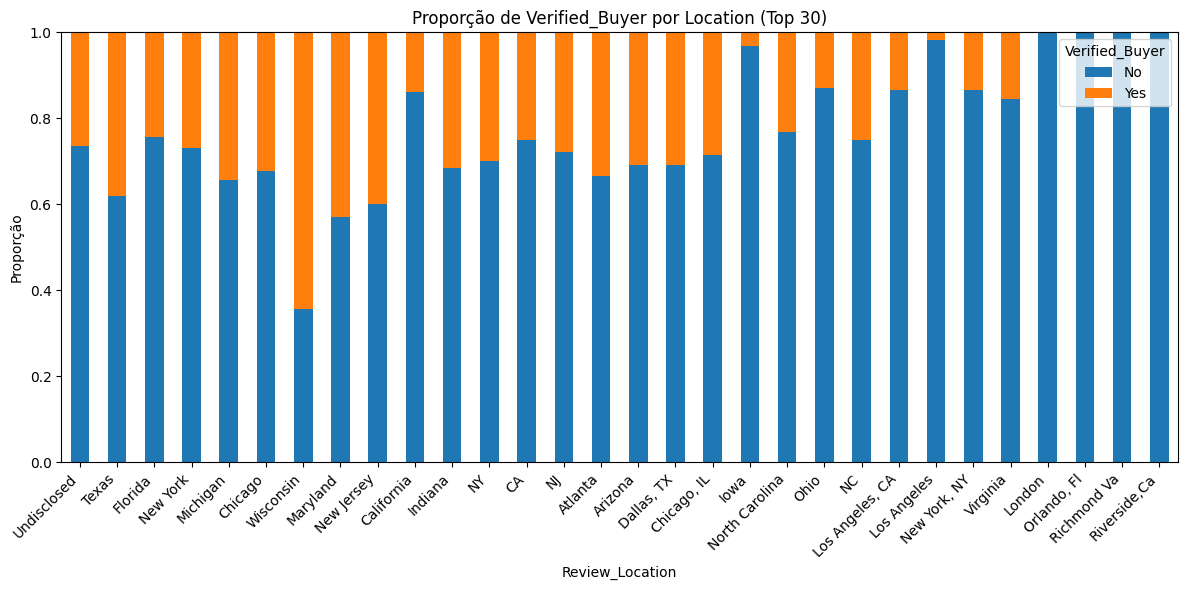

In [53]:
import matplotlib.pyplot as plt

ct_norm.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Proporção de Verified_Buyer por Location (Top 30)")
plt.ylabel("Proporção")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Nota-se que nas top 30 localidades mais representativas existe uma clara dominancia de compradores não verificados.

Agora vamos gerar uma contagem simples nessa top 30 localidades, identificando quantos compradores verificados e não verificados existe em cada uma delas.

In [54]:
df_yes = df[df["Verified_Buyer"] == "Yes"]
df_no  = df[df["Verified_Buyer"] == "No"]
counts_yes = df_yes["Review_Location"].value_counts()
counts_no  = df_no["Review_Location"].value_counts()

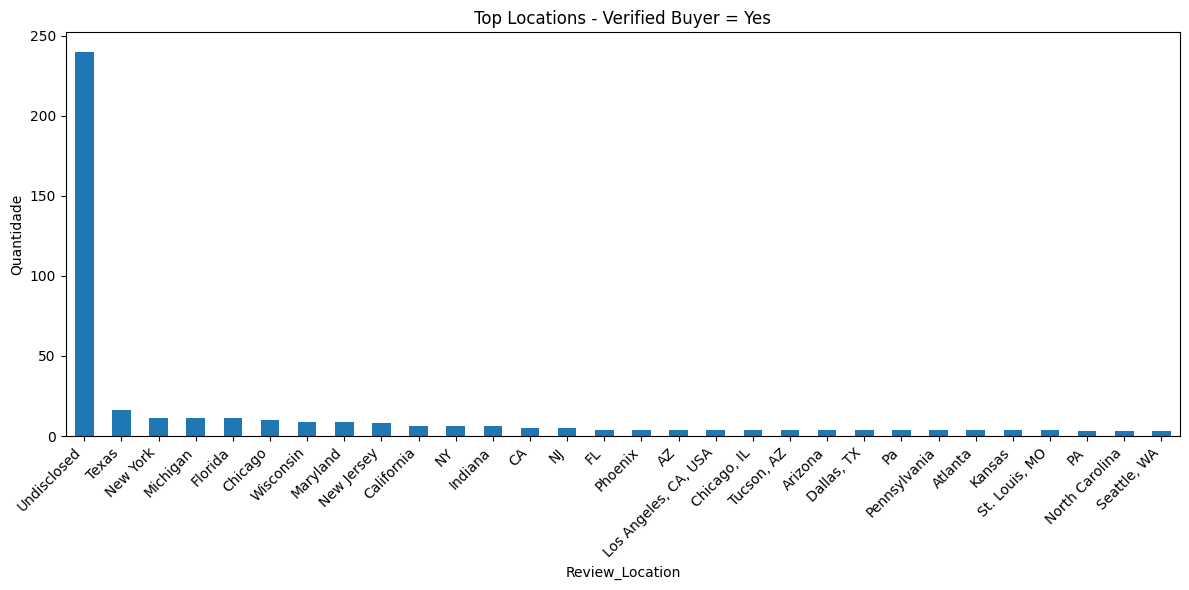

In [55]:
import matplotlib.pyplot as plt

top_n = 30

counts_yes.head(top_n).plot(kind="bar", figsize=(12,6))
plt.title("Top Locations - Verified Buyer = Yes")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

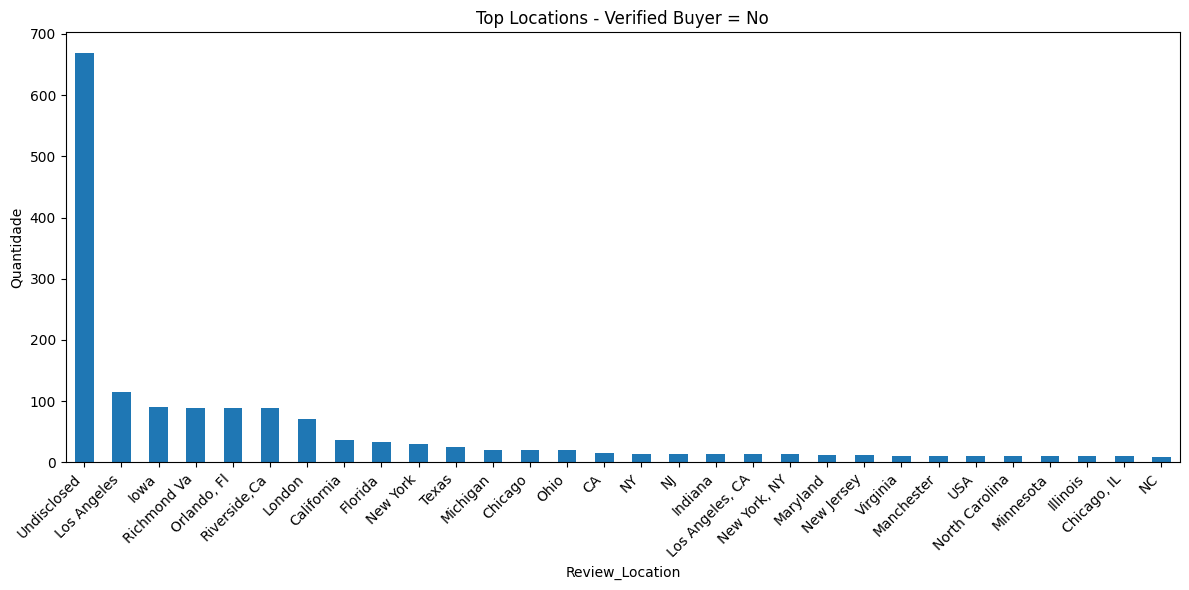

In [56]:
counts_no.head(top_n).plot(kind="bar", figsize=(12,6))
plt.title("Top Locations - Verified Buyer = No")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Além da clara dominancia da classe Verified_Buyer = NO, vemos que existe uma clara dominancia da localidade "Undisclosed" sobre as demais. Devemos ter atenção na forma de codificação desse campo para não distorcer os dados.

### Construindo o pipeline

#### Preparando o dataset

Primeiro vamos preparar o dataset da seguinte forma:

- Concatenando as colunas de texto
- Transformando a informação de localidade em um campo numerico de tipo (0/1) apenas para indicar existencia ou ausencia de informaçao de localidade
- Por fim, eliminando aquelas colunas que não serão utilizadas na vetorização.

In [57]:
# concatenando os titulos e textos
df["Full_Review"] = df["Review_Title"] + " " + df["Review_Text"]

# transformando a coluna Review_Location em um indicador de presença de localização
# pois a distribuição de Location é muito desbalanceada, e Undisclosed é muito mais 
# frequente que qualquer outro.
df["has_location"] = (df["Review_Location"].str.strip().str.lower() != "undisclosed").astype(int)

# descartando as colunas originais e as colunas de data. 
# A depender do resultado, podemos testar posteriormente a inclusão dessas colunas.
df.drop(columns=["Review_Title", "Review_Text", "Review_Date", "Scrape_Date", "Review_Location"], inplace=True)

Agora seraparmos os dados e criamos os conjuntos ```X_train```, ```X_test```, ```y_train```, ```y_test```. Importante notar que vamos fazer isso utilizando a opção de separação estratificada por conta do desbalanceamento existente entre as classes.

In [58]:
X = df.drop('Verified_Buyer', axis=1)
y = df['Verified_Buyer']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

#### Verificando a estratificação das partições

Por fim, comprovamos que a separação dos conjuntos manteve a estratificação das classes existente no dataset.

In [59]:
dist = pd.DataFrame({
    "Original": y.value_counts(),
    "Original (%)": y.value_counts(normalize=True),
    "y_train": y_train.value_counts(),
    "y_train (%)": y_train.value_counts(normalize=True),
    "y_test": y_test.value_counts(),
    "y_test (%)": y_test.value_counts(normalize=True),
})

dist

,Original,Original (%),y_train,y_train (%),y_test,y_test (%)
Verified_Buyer,,,,,,
No,2900,0.699469,2319,0.699337,581,0.7
Yes,1246,0.300531,997,0.300663,249,0.3


#### Montando o ColumnTransformer

Agora vamos proceder com a montagem do processamento completo do dataset. 

Primeiro vamos definir uma classe que nos permitira transformar os parametros da função de pre-processamento em parametros do gridsearch. 

In [60]:
class TextPreprocessor(BaseEstimator):
    def __init__(self, lemma=False, remove_stopwords=False):
        self.lemma = lemma
        self.remove_stopwords = remove_stopwords

    def __call__(self, text):
        return preprocess_text(
            text,
            lemma=self.lemma,
            remove_stopwords=self.remove_stopwords
        )

Agora vamos definir o column transformer. Importante notar que decidimos concientemente não aplicar ```StandardScaler``` nos atributos ```Review_Upvotes``` e ```Review_Downvotes``` por que vamos utilizar o RandomForest, que é essencialmente um ensemble de arvores de decisão. E arvores de decisão não são influenciadas pelas escala dos valores, já que apenas montam condições simples a partir dos valores das features.

In [61]:
# Definindo a coluna e o tipo de transformação:
# 1. texto:
text_atribute = "Full_Review"
text_pipe = Pipeline(steps=[
    (
        "vec",
        TfidfVectorizer(
            preprocessor=TextPreprocessor(),
            min_df=MIN_DF, # Deixa como default aqui, mas o grid search poderia testar outros valores
            max_df=MAX_DF  # Deixa como default aqui, mas o grid search poderia testar outros valores
        )
    ),
    ("svd", TruncatedSVD())
])

# 2. dados categóricos:
categorical_atributes = ['Product', 'Brand']
categorical_transformer = OneHotEncoder()

# 3. dados numéricos:
# Em principio pensei em aplicar o StandardScaler nos Reviews.
# Porém random forest não sofre com a escala, não é relevante.
# numerical_atributes = ['Review_Upvotes', 'Review_Downvotes']
# numeric_transformer = StandardScaler()

# definindo o objeto ColumnTransformer para aplicar as transformações em X:
preprocessor = ColumnTransformer(transformers=[("text", text_pipe, text_atribute),
                                               ('cat', categorical_transformer, categorical_atributes)],
                                 remainder='passthrough' # categorias que não forem identificadas serão consideradas, mas sem transformação
                                )

# visualizando o objeto processador:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

#### Montando o pipeline

E por fim montar o pipeline.

In [62]:
pipe = Pipeline(steps=[('preprocessor', preprocessor),
                       ('classifier', RandomForestClassifier())])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

#### Montando o GridSearch

Para o grid search, utilizaremos a estratégia de GridSearchCV. Vamos incluir, além dos parametros solicitados pela atividade, os parametros da função de pre-processamento, para poder identificar qual a melhor configuração de pre-processamento.

In [63]:
param_grid = {"preprocessor__text__vec__preprocessor__lemma": [True, False],
              "preprocessor__text__vec__preprocessor__remove_stopwords": [True, False],
              'preprocessor__text__svd__n_components':[25, 50, 100],
              'classifier__n_estimators': [30, 60, 90]}

grid_search = GridSearchCV(estimator=pipe,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_estimators': [30, 60, ...], 'preprocessor__text__svd__n_components': [25, 50, ...], 'preprocessor__text__vec__preprocessor__lemma': [True, False], 'preprocessor__text__ve...essor__remove_stopwords': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose

#### Codificando os alvos (y)

Antes de executar o processo de busca, vamos codificar numericamente a variável alvo por que devem ser numéricas.

In [64]:
# definindo o codificador de etiquetas:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train) # fit e transformação
y_test_encoded = le.transform(y_test) # apenas transformação!

print("\nAlvo de treino depois da codificação:")

print(f"Classes aprendidas pelo LabelEncoder: {le.classes_}")
print("Alvos de treino depois da codificação:", y_train_encoded[:10])


Alvo de treino depois da codificação:
Classes aprendidas pelo LabelEncoder: ['No' 'Yes']
Alvos de treino depois da codificação: [0 0 0 1 0 1 1 0 1 0]


### Treinamento e Grid Search

In [65]:
grid_search.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_estimators': [30, 60, ...], 'preprocessor__text__svd__n_components': [25, 50, ...], 'preprocessor__text__vec__preprocessor__lemma': [True, False], 'preprocessor__text__ve...essor__remove_stopwords': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose

In [67]:
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor score de acurácia (validação cruzada): {grid_search.best_score_:.4f}")

Melhores parâmetros encontrados: {'classifier__n_estimators': 90, 'preprocessor__text__svd__n_components': 25, 'preprocessor__text__vec__preprocessor__lemma': False, 'preprocessor__text__vec__preprocessor__remove_stopwords': False}
Melhor score de acurácia (validação cruzada): 0.7880


Interessante notar que a melhor configuração foi justamente aquela que não faz lematização nem remoção de stop words.

### Validação do melhor modelo

In [68]:
y_pred = grid_search.predict(X_test)

acc = accuracy_score(y_test_encoded, y_pred)

print(f"Acurácia do melhor modelo: {acc:.4f}")

Acurácia do melhor modelo: 0.7518


Matriz de Confusão

In [72]:
print("Matriz de confusão:")
print(confusion_matrix(y_test_encoded, y_pred))

Matriz de confusão:
[[540  41]
 [165  84]]


### Classification Report

In [69]:
print("Classification report:\n\n{}".format(classification_report(y_test_encoded, y_pred)))

Classification report:

              precision    recall  f1-score   support

           0       0.77      0.93      0.84       581
           1       0.67      0.34      0.45       249

    accuracy                           0.75       830
   macro avg       0.72      0.63      0.64       830
weighted avg       0.74      0.75      0.72       830



Os numeros mostram que o modelo teve resultados muito diferentes se olhamos para as classes. Enquanto os numero da classe 0 (Verified_Buyer=No) foram altos, os numeros da outra classes foram bem abaixo do esperado. Interessante notar que Precision penaliza falsos positivos e Recall penaliza falsos negativos, portanto, podemos dizer que o modelo foi penalizado em falsos negativos principalmente. Isso significa dizer que o modelo deixa de identificar corretamente uma grande parte dos compradores verificados.

### Melhorando o modelo

Dado o resultado anterior, nossa hipotese inicial é que isso foi causado pelo desbalanceamento das classes: existem muito mais amostras de compradores não verificados que de verificados. Portanto, nosso proximo passo é tentar otimizar os hiperparametros do RandomForest. Em especial o hiperparametro ```class_weight``` poderia nos ajudar, pois ele trabalha justamente sobre o peso das classes. Os valores possiveis são "None" (o default), "Balanced" e "Balanced Subsample". Vamos rodar um novo gridsearch utilizando os melhores parametros encontrados no grid search anterior, e adicionando essas tres opções 

In [73]:
param_grid = {"preprocessor__text__vec__preprocessor__lemma": [False],
              "preprocessor__text__vec__preprocessor__remove_stopwords": [False],
              'preprocessor__text__svd__n_components':[25],
              'classifier__n_estimators': [90],
              'classifier__class_weight': [None, "balanced", "balanced_subsample"]
            }

grid_search = GridSearchCV(estimator=pipe,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced', ...], 'classifier__n_estimators': [90], 'preprocessor__text__svd__n_components': [25], 'preprocessor__text__vec__preprocessor__lemma': [False], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the 

In [74]:
grid_search.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced', ...], 'classifier__n_estimators': [90], 'preprocessor__text__svd__n_components': [25], 'preprocessor__text__vec__preprocessor__lemma': [False], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the 

In [75]:
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor score de acurácia (validação cruzada): {grid_search.best_score_:.4f}")

Melhores parâmetros encontrados: {'classifier__class_weight': None, 'classifier__n_estimators': 90, 'preprocessor__text__svd__n_components': 25, 'preprocessor__text__vec__preprocessor__lemma': False, 'preprocessor__text__vec__preprocessor__remove_stopwords': False}
Melhor score de acurácia (validação cruzada): 0.7762


In [77]:
y_pred = grid_search.predict(X_test)

acc = accuracy_score(y_test_encoded, y_pred)

print(f"Acurácia do melhor modelo: {acc:.4f}")

Acurácia do melhor modelo: 0.7687


In [78]:
print("Classification report:\n\n{}".format(classification_report(y_test_encoded, y_pred)))

Classification report:

              precision    recall  f1-score   support

           0       0.78      0.93      0.85       581
           1       0.71      0.39      0.50       249

    accuracy                           0.77       830
   macro avg       0.74      0.66      0.68       830
weighted avg       0.76      0.77      0.75       830



Houve uma ligeira melhora em precision e recall da classe 1, porém o recall continua baixo. E interessante notar também que a melhor configuração continua o valor de class weight default. Ou seja, nossa hipotese não se confirmou. Isso sugere que o modelo já está proximo do seu limite.

### Ajustando o threshold

Uma alternativa para tentar melhorar as metricas é modificar o threshold do melhor modelo. O threshold é o liminar que define se o modelo classifica como sim um determinado exemplo. Por default o threshold é 0.5, ou seja, entre 0 e 1, se a métrica for 0.5 ou acima o modelo classifica como comprador verificado. Podemos baixar ou subir esse threshold e ver o que acontece com as respectivas métricas. 

O codigo abaixo busca num range de threshold entre 0.1 a 0.6 qual a melhor métrica f1. Escolhemos aqui f1 por ela balanceia melhor a proporção de penalização de falsos positivos e falsos negativos.

In [83]:
# Probabilidades da classe positiva
# Classe 1 = Verified_Buyer == Yes
y_prob = grid_search.predict_proba(X_test)[:, 1]

# Buscar melhor threshold para F1 da classe 1
best_f1 = 0
best_t = 0

for t in [i / 100 for i in range(10, 60)]:
    y_pred_t = (y_prob > t).astype(int)
    f1 = f1_score(y_test_encoded, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"Melhor threshold: {best_t:.2f}")
print(f"Melhor F1 classe 1: {best_f1:.4f}")

# Comparação com threshold padrão do modelo
y_pred_default = grid_search.predict(X_test)

print("\nClassification report com threshold padrão 0.5:\n")
print(classification_report(y_test_encoded, y_pred_default))

print("Matriz de confusão com threshold padrão 0.5:")
print(confusion_matrix(y_test_encoded, y_pred_default))

print(f"\nAccuracy com threshold padrão: {accuracy_score(y_test_encoded, y_pred_default):.4f}")

# Aplicar o melhor threshold
y_pred_threshold = (y_prob > best_t).astype(int)

# Avaliação com threshold ajustado
print("\nClassification report com threshold ajustado:\n")
print(classification_report(y_test_encoded, y_pred_threshold))

print("Matriz de confusão com threshold ajustado:")
print(confusion_matrix(y_test_encoded, y_pred_threshold))

print(f"\nAccuracy com threshold ajustado: {accuracy_score(y_test_encoded, y_pred_threshold):.4f}")

Melhor threshold: 0.34
Melhor F1 classe 1: 0.6460

Classification report com threshold padrão 0.5:

              precision    recall  f1-score   support

           0       0.78      0.93      0.85       581
           1       0.71      0.39      0.50       249

    accuracy                           0.77       830
   macro avg       0.74      0.66      0.68       830
weighted avg       0.76      0.77      0.75       830

Matriz de confusão com threshold padrão 0.5:
[[541  40]
 [152  97]]

Accuracy com threshold padrão: 0.7687

Classification report com threshold ajustado:

              precision    recall  f1-score   support

           0       0.88      0.75      0.81       581
           1       0.56      0.76      0.65       249

    accuracy                           0.75       830
   macro avg       0.72      0.75      0.73       830
weighted avg       0.78      0.75      0.76       830

Matriz de confusão com threshold ajustado:
[[436 145]
 [ 61 188]]

Accuracy com threshold a

Com o threshold em 0.34 melhoramos ligeiramente a acuracia geral do modelo. Penalizamos um pouco a precisão mas melhoramos significativamente o recall. Isso mostra o classico balanço entre precisão em recall: para melhorar o outro piora, e vice-versa. Vamos montar uma curva precision/recall para observar como isso se comporta em nosso problema particular.

In [86]:
from sklearn.metrics import precision_recall_curve

y_prob = grid_search.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test_encoded, y_prob)

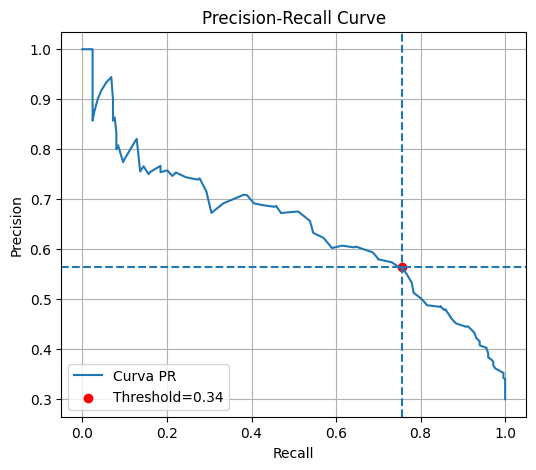

In [87]:
import matplotlib.pyplot as plt

target_threshold = best_t

# encontrar índice mais próximo
idx = np.argmin(np.abs(thresholds - target_threshold))

p = precision[idx]
r = recall[idx]

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label="Curva PR")

# ponto destacado
plt.scatter(r, p, color="red", label=f"Threshold={target_threshold:.2f}")

# linhas tracejadas
plt.axvline(x=r, linestyle="--")
plt.axhline(y=p, linestyle="--")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

Não existe uma escolha certa ou errada, tudo dependerá do objetivo do modelo. Num caso real, deveriamos observar o custo associado ao erro de prever um falso positivo ou um falso negativo para o caso concreto. E só então decidir se queremos ajustar o threshold para uma melhor precisão ou um melhor recall.

O que fizemos aqui foi apenas tentar balancear ambos (utilizando a metrica f1) para encontrar um "ponto médio" ótimo. Mas como já ressaltamos, o importante aqui seria analisar os custos associados a uma previsão equivocada para definir qual o melhor balanço a ser adotado.